In [1]:
%pylab inline
%load_ext autoreload
%autoreload 2

import os,sys
from pathlib import Path
#thisScriptDir = os.path.dirname(os.path.realpath(__file__))
#sys.path.append(os.path.join(thisScriptDir, '../../'))
sys.path.append('/Users/tel/git/lm/utils/python/lm_anal')
cm.jet.set_bad(cm.jet(0))

numpy.set_printoptions(precision=3, threshold=1e6, linewidth=1e6)

Populating the interactive namespace from numpy and matplotlib


In [2]:
from lm_anal.src.magicDict import MagicDict

m = MagicDict()
m[(('hi',1),('lo',3))] = 9
list(m.values())

[9]

In [2]:
from ffluxHistsVsBFHistsExample import FFluxHistsVsBFHistsExample

In [8]:
defaultFilePath = '../../../../../regression/biphasic_switch.lm'

fflux_cppe3FilePath = '/Users/tel/temp_data/gts_fflux_barrier_height_vs_crossingsPerPhase_sweep/theta1.0e+00_cpp1.0e+03/genetic_toggle_switch.lm'
fflux_cppe4FilePath = '/Users/tel/temp_data/gts_fflux_barrier_height_vs_crossingsPerPhase_sweep/theta1.0e+00_cpp1.0e+04/genetic_toggle_switch.lm'
fflux_cppe5FilePath = '/Users/tel/temp_data/gts_fflux_barrier_height_vs_crossingsPerPhase_sweep/theta1.0e+00_cpp1.0e+05/genetic_toggle_switch.lm'
ffluxCppFileList = [fflux_cppe3FilePath, fflux_cppe4FilePath, fflux_cppe5FilePath]

ffluxRootPathLong = '/Users/tel/temp_data/gts_fflux_barrier_height_vs_crossingsPerPhase_sweep/theta1.0e+00_cpp1.0e+05'
ffluxRooPathInterfacesCount = '/Users/tel/temp_data/gts_fflux_barrier_height_vs_crossingsPerPhase_vs_interfacesCount'

fflux_newCppe5FilePath = '../../../../../regression/tmp_genetic_toggle_switch.lm'

fflux_sweepPath = '/Users/tel/temp_data/gts_-_fflux_-_barrier_height_-_crossingsPerPhase_-_phaseZeroTime'

ffluxRootPath = fflux_newCppe5FilePath
ffluxRootPath = Path(ffluxRootPath)
if ffluxRootPath.is_file():
    lmintList = [ffluxRootPath.with_suffix('.lmint')]
else:
    lmintList = ffluxRootPath.rglob('*.lmint')
for lmintPath in lmintList:
    try:
        lmintPath.unlink()
    except FileNotFoundError:
        pass

example = FFluxHistsVsBFHistsExample(ffluxRootPath=ffluxRootPath)
# ffluxHist2D = next(example.ffluxSims.values().__iter__()).ffluxHists[(('InterfaceTilingID', 0), ('BinTilingIDs', (1,2)))]

StopIteration: 

In [4]:
example.ffluxHist2D.plot(figKwargs={'figsize':(18,18)})

AttributeError: 'FFluxHistsVsBFHistsExample' object has no attribute 'ffluxHist2D'

In [5]:
example.bfHist.normalize()
histArr = (example.bfHist.h - example.ffluxHist2D.h)/example.bfHist.h
print(example.bfHist.getKLDivergence(example.ffluxHist2D))
print(np.sum(example.bfHist.h))
print(np.sum(example.ffluxHist2D.h))

AttributeError: 'FFluxHistsVsBFHistsExample' object has no attribute 'ffluxHist2D'

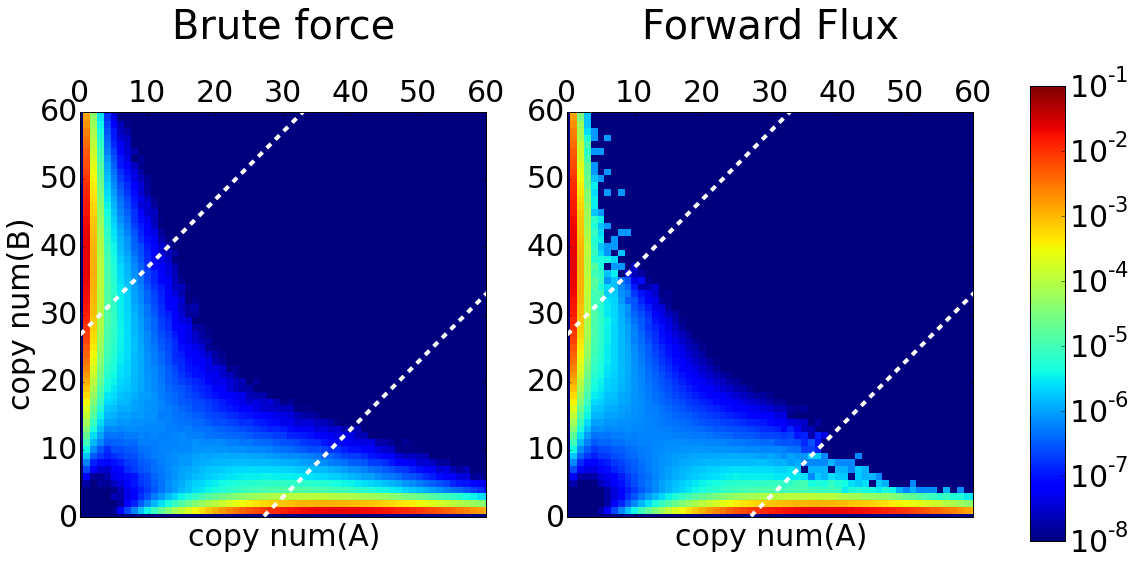

In [108]:
from matplotlib.colors import LogNorm
matplotlib.rcParams.update({'font.size': 30})

fig, axArr = plt.subplots(1, 2)
fig.set_size_inches(16,8)
axcolor = fig.add_axes([0.95, 0.12, 0.03, 0.79])
titles = ['Brute force', 'Forward Flux']
for ax,hist,title in zip(axArr, (example.bfHist.h, example.ffluxHist2D.h), titles):
    t = np.logspace(-4,10,base=10,num=20)
#     ax.plot((1,2),(3,4))
    im = ax.matshow(hist, cmap=cm.jet, origin='lower',norm=LogNorm(), vmin=1e-8, vmax=1e-1)
    for b in (27,-27):
        ax.plot((-5, 100), (-5+b, 100+b), 'w--', linewidth=4)
#     for b in (25,-25):
#         ax.plot((-5, 100), (-5+b, 100+b), 'w--', linewidth=4)
    ax.set_xlim(0,60)
    ax.set_ylim(0,60)
    ax.set_xlabel('copy num(A)')
#     ax.set_ylabel('copy num(B)')
    ax.set_title(title, y=1.17, fontsize=40)
axArr[0].set_ylabel('copy num(B)')
fig.colorbar(im, cax=axcolor)#, ticks=t, format='$%.2e$')

(0, 60)

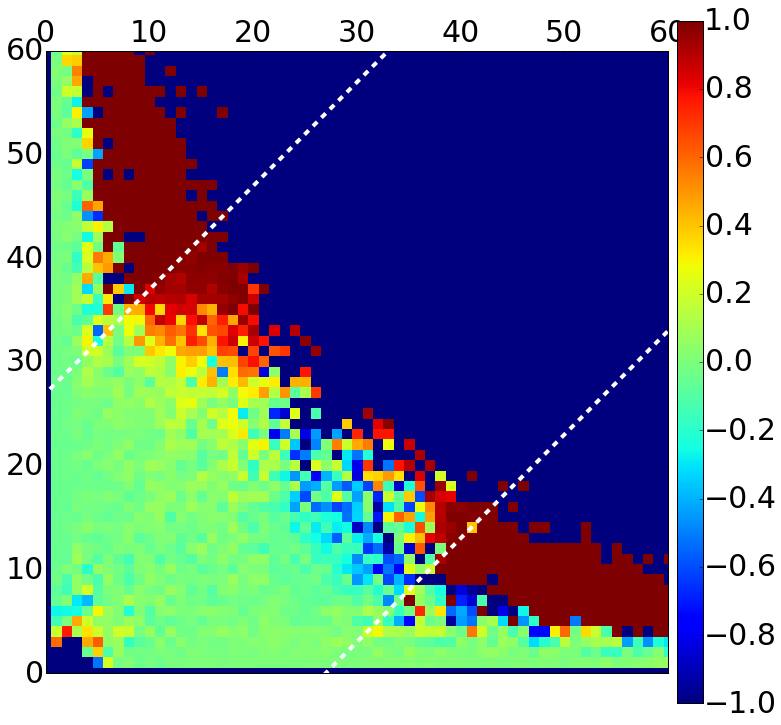

In [14]:
from matplotlib.colors import LogNorm
fig = figure(figsize=(12,12))
ax = fig.add_axes([0.17, 0.02, 0.72, 0.79])
axcolor = fig.add_axes([0.90, 0.02, 0.03, 0.79])
t = np.logspace(-4,10,base=10,num=20)
im = ax.matshow(histArr, cmap=cm.jet, origin='lower',vmin=-1, vmax=1)# norm=LogNorm())
for b in (27,-27):
    ax.plot((-5, 100), (-5+b, 100+b), 'w--', linewidth=4)
fig.colorbar(im, cax=axcolor)#, ticks=t, format='$%.2e$')
ax.set_xlim(0,60)
ax.set_ylim(0,60)

In [125]:
modFFluxArr = example.ffluxHist2D.basin_n_order_parameter_values[('basin_id', 0)].combine( \
              example.ffluxHist2D.basin_n_order_parameter_values[('basin_id', 1)])
modBFArr = example.bfHist.getCopy()

zeroMask = np.logical_or(modFFluxArr.h==0, modBFArr.h==0)
transitionMask = np.ones(modFFluxArr.h.shape, dtype=bool)
transitionMask[10:21,10:21] = False
# transitionMask = np.logical_or(transitionMask, zeroMask)

modBFArr.remask(transitionMask)
# modBFArr.normalize()
modFFluxArr.remask(transitionMask)
# modFFluxArr.normalize()
print(modBFArr.getKLDivergence(modFFluxArr, normalize=True))

modBFArr.remask(zeroMask)
modBFArr.normalize()
modFFluxArr.remask(zeroMask)
modFFluxArr.normalize()
print(modBFArr.getKLDivergence(modFFluxArr))

print(np.sum(modFFluxArr.h))
print(np.sum(modBFArr.h))
print(np.all(modFFluxArr.h.nonzero()[0]==modBFArr.h.nonzero()[0]))
print(np.all(modFFluxArr.h.nonzero()[1]==modBFArr.h.nonzero()[1]))
print(np.any((modFFluxArr.h==modBFArr.h)))
print(np.any(np.isnan((modBFArr.h - modFFluxArr.h)/modBFArr.h)))
stdErrArr = (modBFArr.h - modFFluxArr.h)/modBFArr.h
klDivArr = modBFArr.h*np.log(modBFArr.h/modFFluxArr.h)
klDivArr[np.isnan(klDivArr)] = 0

bfStdErrArr = (modBFArr.h - modBFArr.h.T)/modBFArr.h
bfKLDivArr = modBFArr.h*np.log(modBFArr.h/modBFArr.h.T)
bfKLDivArr[np.isnan(bfKLDivArr)] = 0

ffStdErrArr = (modFFluxArr.h - modFFluxArr.h.T)/modFFluxArr.h
ffKLDivArr = modFFluxArr.h*np.log(modFFluxArr.h/modFFluxArr.h.T)
ffKLDivArr[np.isnan(ffKLDivArr)] = 0

print(klDivArr.sum())
print(klDivArr[10:21,10:21].sum())

0.00133554905715
0.000390732273803
1.0
1.0
True
True
True
True
0.000390732273803
1.31071836343e-05


/usr/local/lib/python3.4/site-packages/ipykernel/__main__.py:26: RuntimeWarning: invalid value encountered in true_divide
/usr/local/lib/python3.4/site-packages/ipykernel/__main__.py:27: RuntimeWarning: invalid value encountered in true_divide
/usr/local/lib/python3.4/site-packages/ipykernel/__main__.py:28: RuntimeWarning: invalid value encountered in true_divide
/usr/local/lib/python3.4/site-packages/ipykernel/__main__.py:31: RuntimeWarning: divide by zero encountered in true_divide
/usr/local/lib/python3.4/site-packages/ipykernel/__main__.py:31: RuntimeWarning: invalid value encountered in true_divide
/usr/local/lib/python3.4/site-packages/ipykernel/__main__.py:32: RuntimeWarning: divide by zero encountered in true_divide
/usr/local/lib/python3.4/site-packages/ipykernel/__main__.py:32: RuntimeWarning: invalid value encountered in true_divide
/usr/local/lib/python3.4/site-packages/ipykernel/__main__.py:32: RuntimeWarning: divide by zero encountered in log
/usr/local/lib/python3.4/site

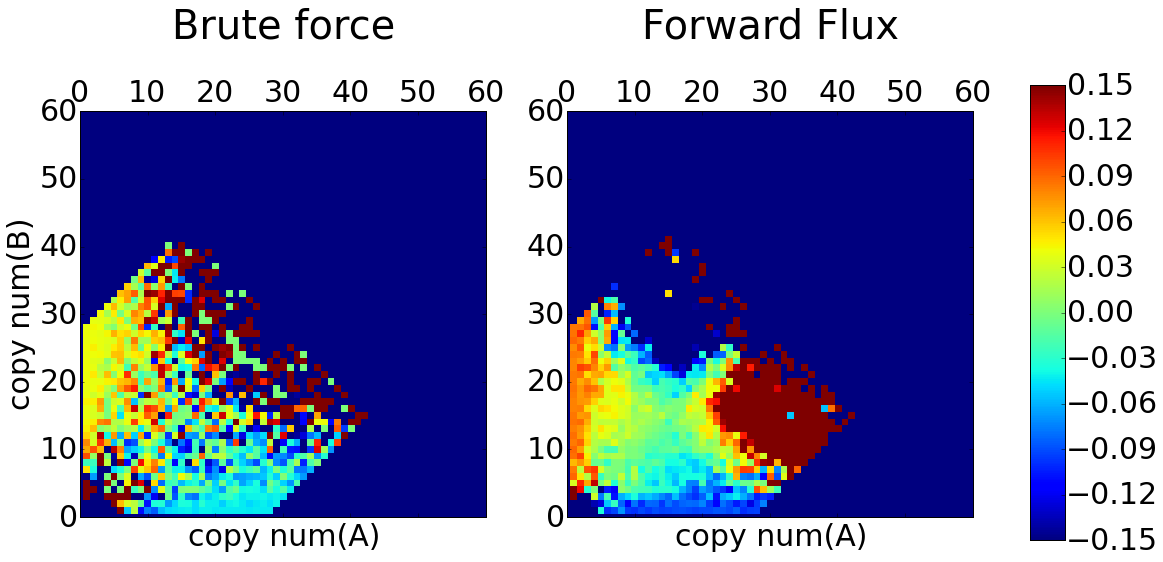

In [131]:
matplotlib.rcParams.update({'font.size': 30})

fig, axArr = plt.subplots(1, 2)
fig.set_size_inches(16,8)
axcolor = fig.add_axes([0.95, 0.12, 0.03, 0.79])
titles = ['Brute force', 'Forward Flux']
for ax,hist,title in zip(axArr, (bfStdErrArr, ffStdErrArr), titles):
    t = np.logspace(-4,10,base=10,num=20)
#     ax.plot((1,2),(3,4))
    im = ax.matshow(hist, cmap=cm.jet, origin='lower',vmin=-.15, vmax=.15)#, norm=LogNorm(), vmin=1e-8, vmax=1e-1)
#     for b in (25,-25):
#         ax.plot((-5, 100), (-5+b, 100+b), 'w--', linewidth=4)
    fig.colorbar(im, cax=axcolor, ticks=t, format='$%.2e$')
    ax.set_xlim(0,60)
    ax.set_ylim(0,60)
    ax.set_xlabel('copy num(A)')
#     ax.set_ylabel('copy num(B)')
    ax.set_title(title, y=1.17, fontsize=40)
axArr[0].set_ylabel('copy num(B)')
fig.colorbar(im, cax=axcolor)


(0, 60)

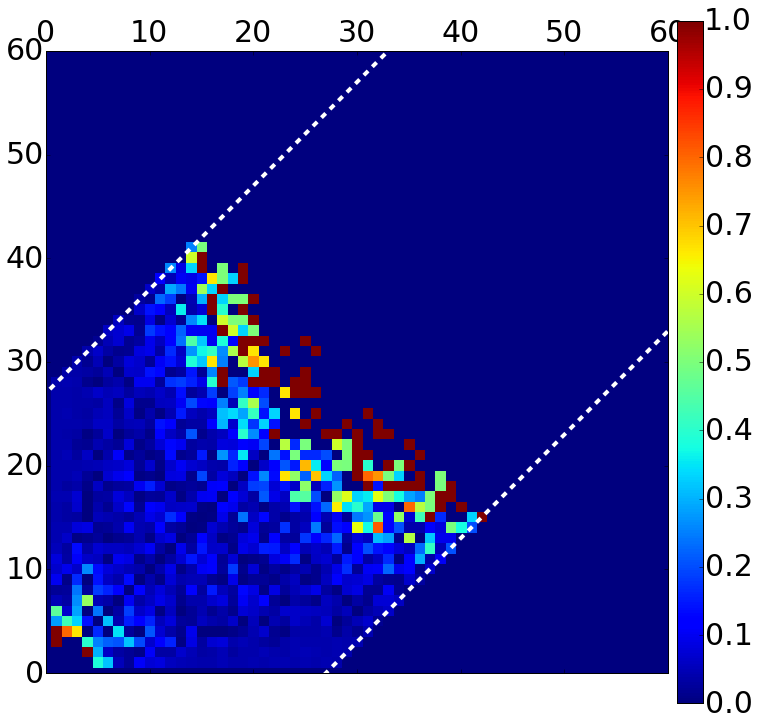

In [124]:
from matplotlib.colors import LogNorm
f = figure(figsize=(12,12))
ax = f.add_axes([0.17, 0.02, 0.72, 0.79])
axcolor = f.add_axes([0.90, 0.02, 0.03, 0.79])
t = np.logspace(-4,10,base=10,num=20)
im = ax.matshow(np.abs(stdErrArr), cmap=cm.jet, origin='lower',vmin=0, vmax=1) #, norm=LogNorm())
for b in (27,-27):
    ax.plot((-5, 100), (-5+b, 100+b), 'w--', linewidth=4)
f.colorbar(im, cax=axcolor)#, ticks=t, format='$%.2e$')
ax.set_xlim(0,60)
ax.set_ylim(0,60)

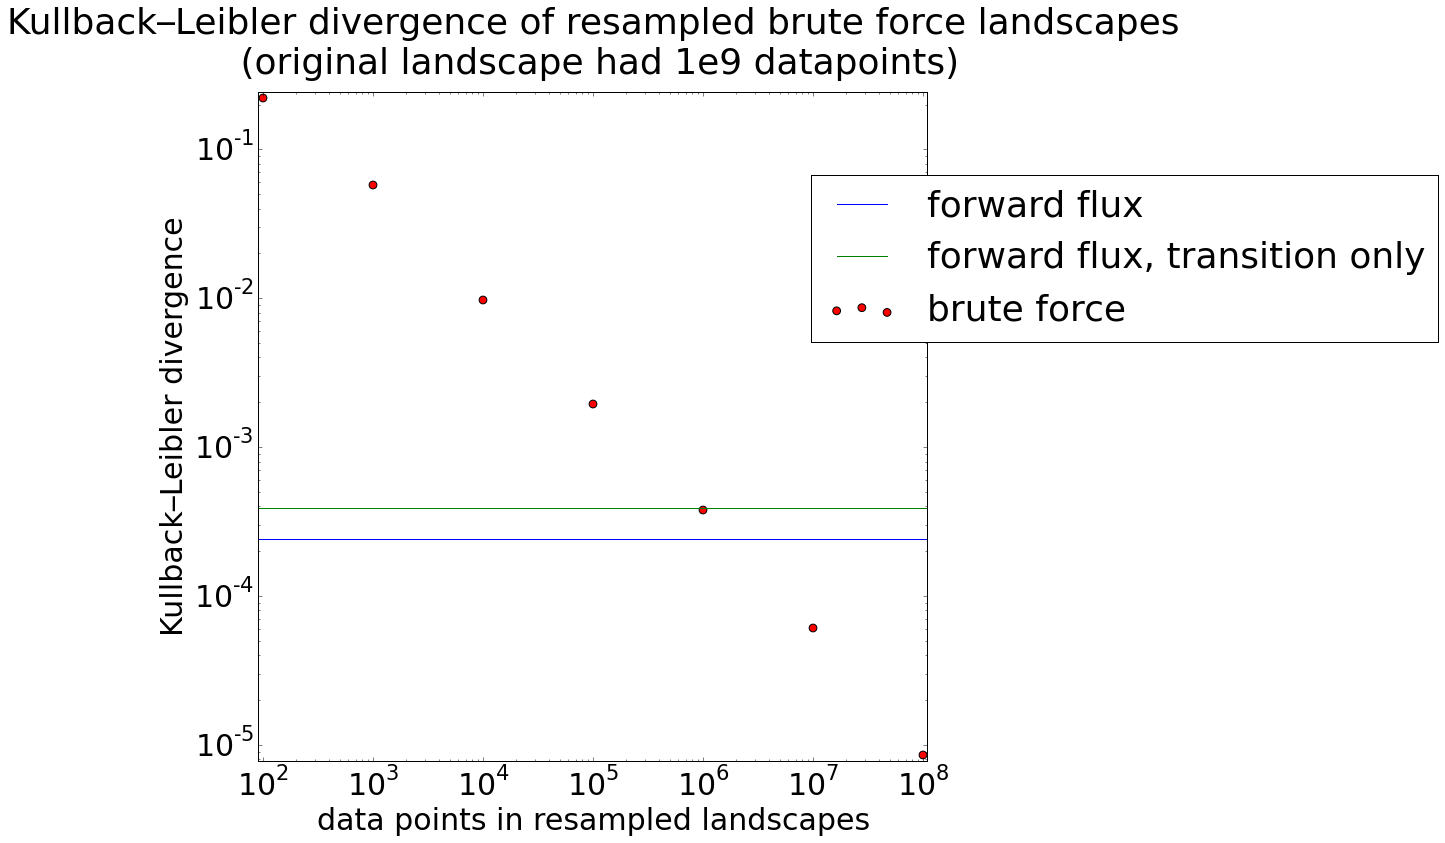

In [109]:
resample_count = [100, 1000, 10000, 100000, 1000000, 10000000, 100000000]
resample_klDiv = [0.22115484214190989, 0.058052515738895256, 0.0097402208107240529, 0.0019470898399369212, 0.00038031473057596884, 6.0862781067080629e-05, 8.6023991989453894e-06]
fig = figure(figsize=(12,12))
ax = fig.gca()
ax.scatter(resample_count, resample_klDiv, c='r', s=60, label='brute force')
horiz_line_x = (min(resample_count) - .1*min(resample_count), max(resample_count) + .1*max(resample_count))
ax.plot(horiz_line_x, [0.000240342931422]*2, label='forward flux')
ax.plot(horiz_line_x, [0.000390732273803]*2, label='forward flux, transition only')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(loc='lower left', bbox_to_anchor=(0.8, 0.6))
ax.set_xlim(min(resample_count) - .1*min(resample_count), max(resample_count) + .1*max(resample_count))
ax.set_ylim(min(resample_klDiv) - .1*min(resample_klDiv), max(resample_klDiv) + .1*max(resample_klDiv))

ax.set_xlabel('data points in resampled landscapes')
ax.set_ylabel('Kullback–Leibler divergence')

ax.set_title('Kullback–Leibler divergence of resampled brute force landscapes\n (original landscape had 1e9 datapoints)',y=1.02)

NameError: name 'ffluxHist2D' is not defined

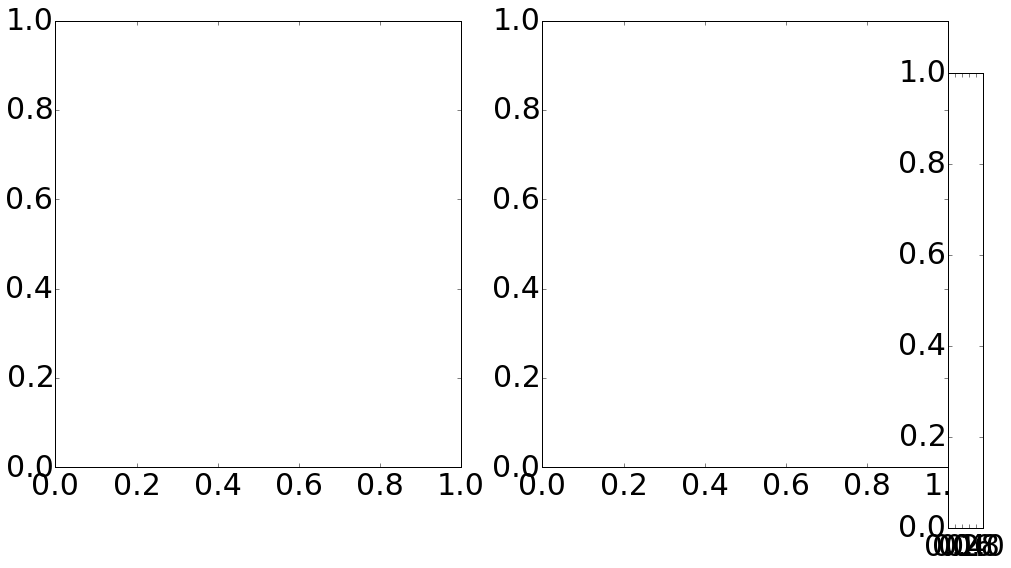

In [49]:
from matplotlib.colors import LogNorm
matplotlib.rcParams.update({'font.size': 30})

fig, axArr = plt.subplots(1, 2)
fig.set_size_inches(16,8)
axcolor = fig.add_axes([0.90, 0.02, 0.03, 0.79])
for ax,hist in zip(axArr, [histDatum.h_raw for histDatum in ffluxHist2D.phase_zero_order_parameter_values.values()]):
    t = np.logspace(-4,10,base=10,num=20)
#     ax.plot((1,2),(3,4))
    im = ax.matshow(hist, cmap=cm.jet, origin='lower',norm=LogNorm())#, vmin=1e-8, vmax=1e-1)
#     for b in (25,-25):
#         ax.plot((-5, 100), (-5+b, 100+b), 'w--', linewidth=4)
#     fig.colorbar(im, cax=axcolor, ticks=t, format='$%.2e$')
    ax.set_xlim(0,60)
    ax.set_ylim(0,60)
    ax.set_xlabel('copy num(A)')
#     ax.set_ylabel('copy num(B)')
axArr[0].set_ylabel('copy num(B)')
fig.colorbar(im, cax=axcolor)


In [6]:
bfHistNorm = example.bfHist.getCopy()
bfHistNorm.normalize()
bf1d = np.array((np.arange(-100,101),[bfHistNorm.h.trace(offset=i) for i in np.arange(-100,101)]))
ffluxHistNorm = example.ffluxHist.getCopy()
ffluxHistNorm.normalize()
fflux1d = np.array((np.arange(-100,100), ffluxHistNorm.h))
fflux1dzf = np.array((np.arange(-100,100), ffluxHistNorm.phase_n_order_parameter_values[('basin_id',0),('phase_id',0)].h_raw))
fflux1dzb = np.array((np.arange(-100,100), ffluxHistNorm.phase_n_order_parameter_values[('basin_id',1),('phase_id',0)].h_raw))
# fflux1d = np.array((np.arange(-100,101), [ffluxHistNorm.h.trace(offset=i) for i in np.arange(-100,101)]))
print(fflux1d[1].shape)

AttributeError: 'FFluxHistsVsBFHistsExample' object has no attribute 'ffluxHist'

In [ ]:
start,end=bf1d[0].searchsorted((-35,35))
print(start,end)
# bf1d[1,start:end]
np.linspace(-29,29,3)

0.000180754930675


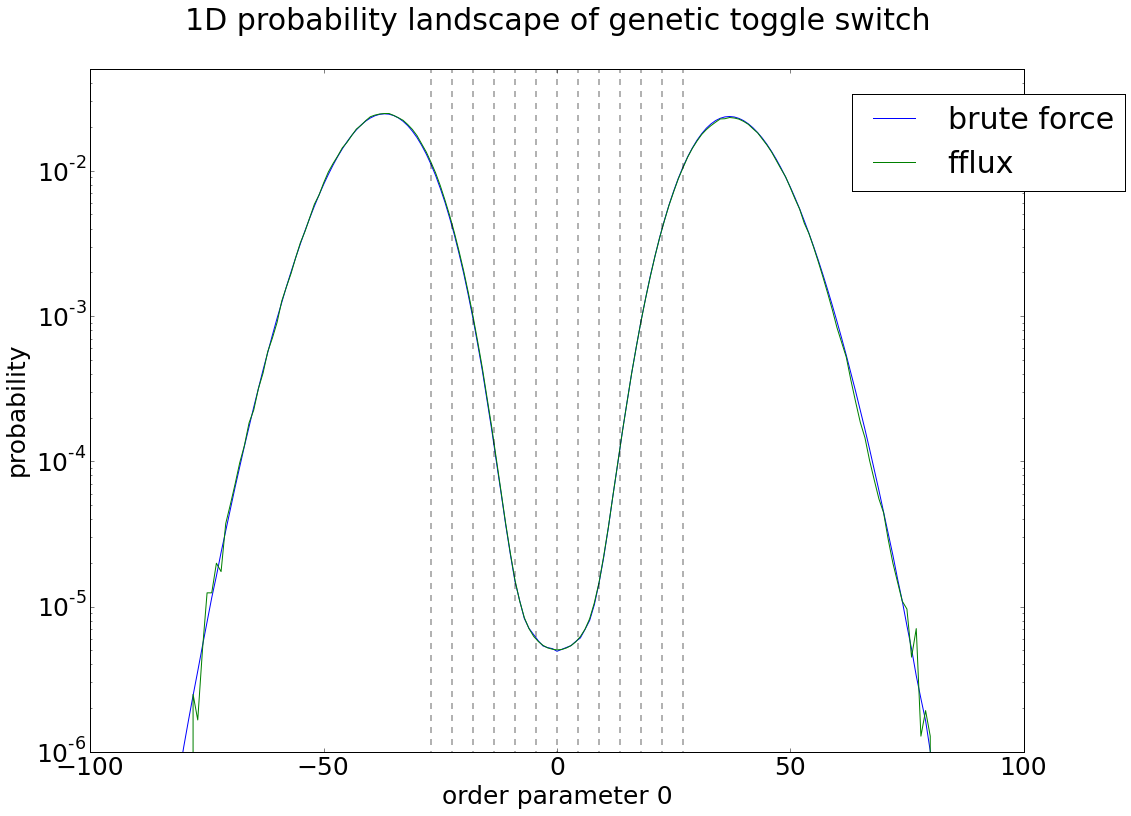

In [77]:
# normalized across everything
matplotlib.rcParams.update({'font.size': 25})

import scipy.stats as st

f = figure(figsize=(18,12))
ax = f.add_axes([0.17, 0.02, 0.72, 0.79])
ax.plot(bf1d[0], bf1d[1]/bf1d[1].sum(), label='brute force')
ax.plot(fflux1d[0], fflux1d[1]/fflux1d[1].sum(), label='fflux')
for b in np.linspace(-27,27,13):
    ax.plot((b, b), (1e-10, 1e0), 'k--', linewidth=2, alpha=0.3)
# for b in [-27,-25,-22,-18,-14,-12,-8,-5,-2,0,10,20]:
#     ax.plot((b, b), (1e-10, 1e0), 'k--', linewidth=2, alpha=0.3)
ax.legend(loc='lower left', bbox_to_anchor=(0.8, 0.8))  #loc='upper right')
ax.set_xlim(-100,100)
ax.set_ylim(1e-6,5e-2)
ax.set_yscale('log')
ax.set_xlabel('order parameter 0')
ax.set_ylabel('probability')
ax.set_title('1D probability landscape of genetic toggle switch', y=1.05);
print(st.entropy(pk=bf1d[1][35:165]/bf1d[1][35:165].sum(), qk=fflux1d[1][35:165]/fflux1d[1][35:165].sum()))

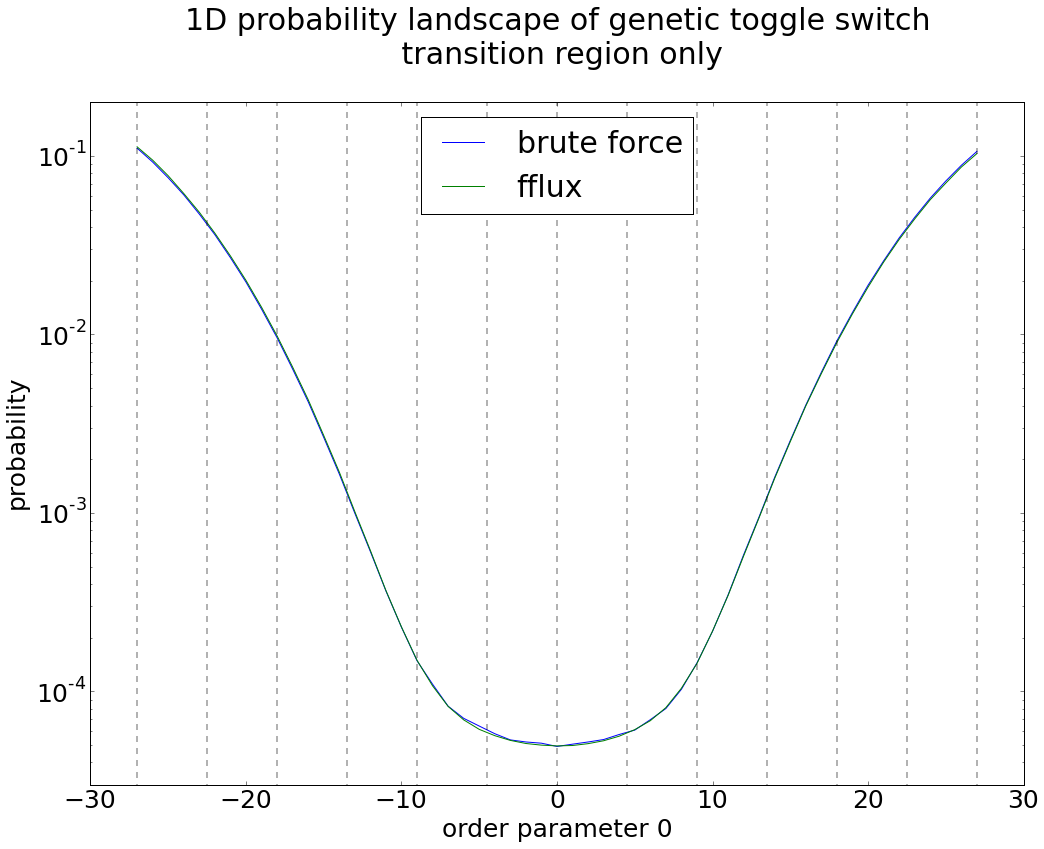

In [79]:
# normalized over xmin-xmax

xmin,xmax=-27,27
s,e=bf1d[0].searchsorted((xmin,xmax)) + np.array([0,1])
bf1dTrans = bf1d[:,s:e]
fflux1dTrans = fflux1d[:,s:e]

f = figure(figsize=(18,12))
ax = f.add_axes([0.17, 0.02, 0.72, 0.79])
ax.plot(bf1dTrans[0], bf1dTrans[1]/bf1dTrans[1].sum(), label='brute force')
ax.plot(fflux1dTrans[0], fflux1dTrans[1]/fflux1dTrans[1].sum(), label='fflux')
for b in np.linspace(-27,27,13):
    ax.plot((b, b), (1e-10, 1e0), 'k--', linewidth=2, alpha=0.3)
ax.legend(loc='best')
ax.set_yscale('log')
ax.set_ylim(3e-5,2e-1)
ax.set_xlim(-30, 30)

ax.set_xlabel('order parameter 0');
ax.set_ylabel('probability');
ax.set_title('1D probability landscape of genetic toggle switch\n transition region only', y=1.05);

# print(st.entropy(pk=bf1dTrans[1]/bf1dTrans[1].sum(), qk=fflux1dTrans[1]/fflux1dTrans[1].sum()))

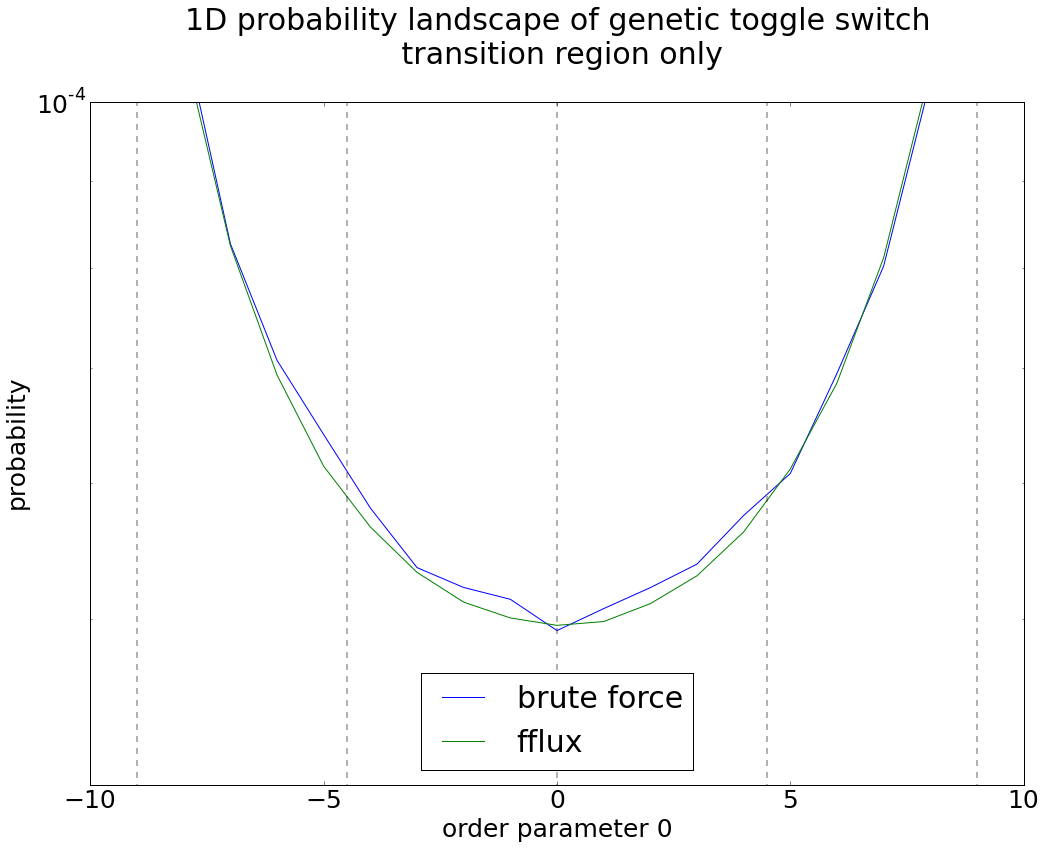

In [83]:
# normalized over xmin-xmax

xmin,xmax=-27,27
s,e=bf1d[0].searchsorted((xmin,xmax)) + np.array([0,1])
bf1dTrans = bf1d[:,s:e]
fflux1dTrans = fflux1d[:,s:e]

f = figure(figsize=(18,12))
ax = f.add_axes([0.17, 0.02, 0.72, 0.79])
ax.plot(bf1dTrans[0], bf1dTrans[1]/bf1dTrans[1].sum(), label='brute force')
ax.plot(fflux1dTrans[0], fflux1dTrans[1]/fflux1dTrans[1].sum(), label='fflux')
for b in np.linspace(-27,27,13):
    ax.plot((b, b), (1e-10, 1e0), 'k--', linewidth=2, alpha=0.3)
ax.legend(loc='best')
ax.set_yscale('log')
ax.set_ylim(4e-5,1e-4)
ax.set_xlim(-10, 10)

ax.set_xlabel('order parameter 0');
ax.set_ylabel('probability');
ax.set_title('1D probability landscape of genetic toggle switch\n transition region only', y=1.05);

# print(st.entropy(pk=bf1dTrans[1]/bf1dTrans[1].sum(), qk=fflux1dTrans[1]/fflux1dTrans[1].sum()))

In [ ]:
f = figure(figsize=(18,12))
ax = f.gca()

ax.plot()

[   0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    2.    2.    6.    5.    7.    5.    5.   11.   22.   21.   18.   34.   30.   37.   64.   71.   87.  149.  140.  184.  182.  249.  257.  334.  377.  378.  407.  437.  443.  434.  459.  500.  530.  451.  443.  472.  393.  355.  357.  311.  271.  221.  194.  133.  122.  103.   85.   51.   44.   29.   25.   16.   20.    9.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    

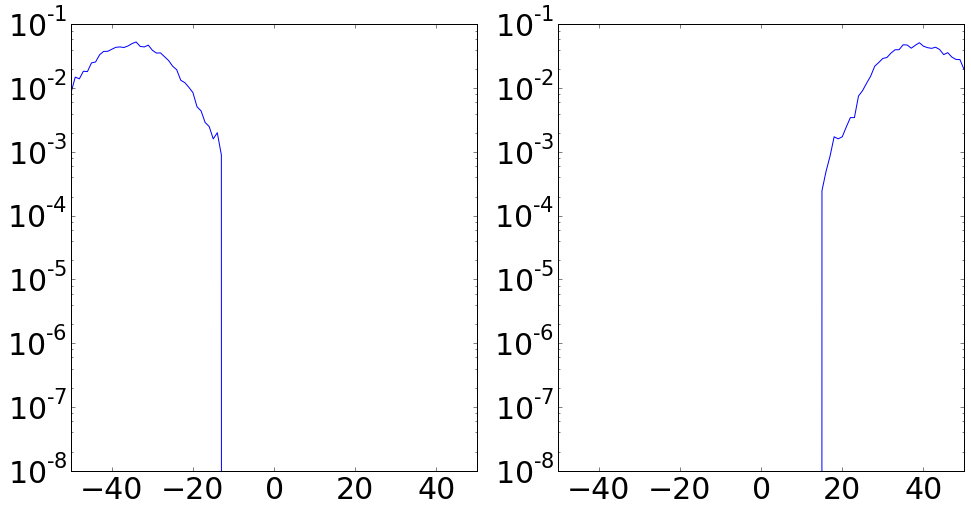

In [8]:
from matplotlib.colors import LogNorm
matplotlib.rcParams.update({'font.size': 30})

fig, axArr = plt.subplots(1, 2)
fig.set_size_inches(16,8)
for ax,hist in zip(axArr, (fflux1dzf,fflux1dzb)):
    print(hist[1])
    im = ax.plot(hist[0], hist[1]/hist[1].sum())
    ax.set_ylim(1e-8,1e-1)
    ax.set_xlim(-50, 50)
    ax.set_yscale('log')

In [9]:
# normalized over -5,5

xmin,xmax=-35,35
s,e=bf1d[0].searchsorted((xmin,xmax)) + np.array([0,1])
bf1dTrans = bf1d[:,s:e]
fflux1d_wi04Trans = fflux1d_wi04[:,s:e]
fflux1d_wi1Trans = fflux1d_wi1[:,s:e]
fflux1d_wi4Trans = fflux1d_wi4[:,s:e]

f = figure(figsize=(18,12))
ax = f.add_axes([0.17, 0.02, 0.72, 0.79])
ax.plot(bf1dTrans[0], bf1dTrans[1]/bf1dTrans[1][-5-xmin:6-xmin].sum(), label='brute force')
ax.plot(fflux1d_wi04Trans[0], fflux1d_wi04Trans[1]/fflux1d_wi04Trans[1][-5-xmin:6-xmin].sum(), label='fflux, write interval 0.4')
ax.plot(fflux1d_wi1Trans[0], fflux1d_wi1Trans[1]/fflux1d_wi1Trans[1][-5-xmin:6-xmin].sum(), label='fflux, write interval 1.0')
ax.plot(fflux1d_wi4Trans[0], fflux1d_wi4Trans[1]/fflux1d_wi4Trans[1][-5-xmin:6-xmin].sum(), label='fflux, write interval 4.0')
ax.legend(loc='best')
ax.set_yscale('log')
ax.set_ylim(1e-3,1e3)
ax.set_xlim(xmin, xmax)

NameError: name 'fflux1d_wi04' is not defined

In [ ]:
xmin,xmax=-100,100
s,e=bf1d[0].searchsorted((xmin,xmax))
bf1dTrans = bf1d[:,s:e]
fflux1dTrans = fflux1d[:,s:e]

f = figure(figsize=(12,12))
ax = f.add_axes([0.17, 0.02, 0.72, 0.79])
ax.plot(bf1dTrans[0], bf1dTrans[1]/bf1dTrans[1].sum())
ax.plot(np.linspace(-25-(25/12),25+(25/12),14), examplee3.ffluxHist.h)
ax.plot(np.linspace(-25-(25/12),25+(25/12),14), examplee4.ffluxHist.h)
ax.plot(np.linspace(-25-(25/12),25+(25/12),14), examplee5.ffluxHist.h)
# ax.plot(example.ffluxHist.h.trace())
ax.set_yscale('log')
ax.set_xlim(-25, 25)

In [ ]:
examplee5.ffluxHist.h[1:-1]

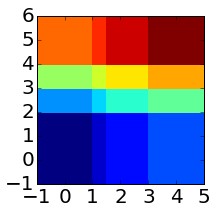

In [15]:
fig = plt.figure(figsize=(3,3))
ax = fig.gca()

xedges = [-1, 1, 1.5, 3, 5]
yedges = [-1, 2, 3, 4, 6]
H = np.ones((4,4)).cumsum().reshape(4, 4)
X, Y = np.meshgrid(xedges, yedges)
ax.pcolormesh(X, Y, H)